In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy


from scipy.optimize import curve_fit

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
odir1 = "../../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM12.0-12.5.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk110 = pickle.load(f)
print("shotnoise", Pk110.attrs["shotnoise"])

shotnoise 926.3583221039135


In [4]:
def my_cf(k_values, power_spectrum_values, r_values):
    xi_values = np.zeros_like(r_values)
    dk = k_values[1] - k_values[0]
    
    for i, r in enumerate(r_values):
        integral = np.sum(power_spectrum_values * np.sin(k_values * r) / (k_values * r) * k_values**2 * dk)
        xi_values[i] = integral / (2 * np.pi**2)
    
    return xi_values

In [5]:
import colossus.cosmology
from colossus.lss import bias as colossus_bias
cosmo = colossus.cosmology.cosmology.setCosmology("planck15")

bias_model = "sheth01"

z=1.5
bias0 = colossus_bias.haloBias(10**11, model=bias_model, z=z)
print(bias0)
bias0 = colossus_bias.haloBias(10**11.1, model=bias_model, z=z)
print(bias0)

bias_model = "comparat17"

z=1.5
bias0 = colossus_bias.haloBias(10**12, model=bias_model, z=z)
print(bias0)
bias1 = colossus_bias.haloBias(10**12.5, model=bias_model, z=z)
print(bias1)
b_const = (bias0 + bias1)/2

1.254501032663919
1.2930499593363445
1.6994876624870987
2.2407129379679405


In [6]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

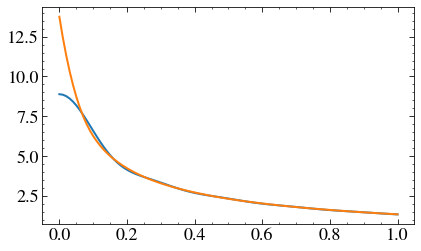

In [7]:
nbins = 100
ks = np.linspace(10**-1.5, 10**1.5, 10000)
r = np.linspace(1e-4, 1, nbins)

xi = my_cf(ks, Plin(ks),r)
plt.plot(r,xi)
plt.plot(r,cf_lin(r))

In [8]:
def kernel_lin(ks, R=1, nbins=100):
    dx = 2*R
    results = []
    r = np.linspace(0, dx, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [9]:
def kernel_NL(ks, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(0, dx, nbins)
    xi = cf_nl(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [10]:
def correlation_function(k_values, power_spectrum_values, r_values):
    xi_values = np.zeros_like(r_values)
    dk = k_values[1] - k_values[0]
    
    for i, r in enumerate(r_values):
        integral = np.sum(power_spectrum_values * np.sin(k_values * r) / (k_values * r) * k_values**2 * dk)
        xi_values[i] = integral / (2 * np.pi**2)
    
    return xi_values

In [11]:
def kernel_new(ks, xi, pk, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(1e-4, dx, nbins)
    xi = correlation_function(ks, pk,r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [12]:
def W_R(k, R=1):
    R = 2*R
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [13]:
def V_excl(R=1):
    R = 2*R
    return (4*np.pi*R**3)/3

In [14]:
def pk_random(k, R):
    result2 = -V_excl(R)*W_R(k,R)
    return result2

In [15]:
def fit_pow(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1, kernel_type="lin"):
    #bias_k = scale_dependent_bias(logk, a, b, c, d, logk0)
    bias_k = 5
    bias_factor = bias_k**2
    
    mask = logk > -0.3
    bias_factor_k = np.full(len(logk), bias_factor)
    #bias_factor_k[mask] = bias_factor*0.5
    #bias_factor_k = poly3(logk, *pop_fit1)

    #mask = logk < logk0
    #result[mask] = a
    if kernel_type == "lin":
        Pk = Plin(10**logk)
        kernel = kernel_lin(10**logk, R=R)
    elif kernel_type == "new":
        
        kernel = kernel_new(10**logk, R=R)
    elif kernel_type == "nl":
        Pk = Pnl(10**logk)
        kernel = kernel_NL(10**logk, R=R)
    
    result1 = bias_factor_k*Pk - bias_factor_k*kernel - V_excl(R)*W_R(10**logk, R)
    
    return result1

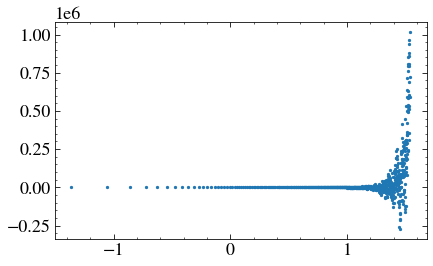

In [16]:
kcoef_tng = Pk110["k"]**3/(2*np.pi**2)
plt.scatter(np.log10(Pk110["k"]),kcoef_tng*(Pk110["power"].real-Pk110.attrs["shotnoise"])/Plin(Pk110["k"]), s=5, label="logM11-11.5")
#plt.ylim(-100,100)

(-100.0, 100.0)

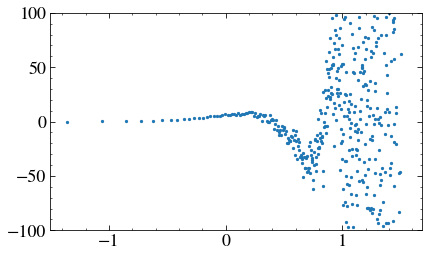

In [19]:
kcoef_tng = Pk110["k"]**3/(2*np.pi**2)
plt.scatter(np.log10(Pk110["k"]),kcoef_tng*(Pk110["power"].real-Pk110.attrs["shotnoise"]), s=5, label="logM11-11.5")
plt.ylim(-100,100)

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

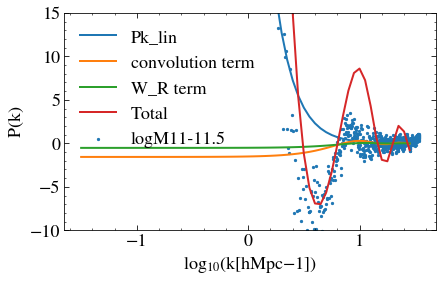

In [20]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.25

b_factor = b_const**2
plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Plin(10**logks), label="Pk_lin")
plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow(logks,R=R), label="Total")
#plt.ylim(-1,500)
plt.ylim(-10,15)
#plt.ylim(-2,2)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

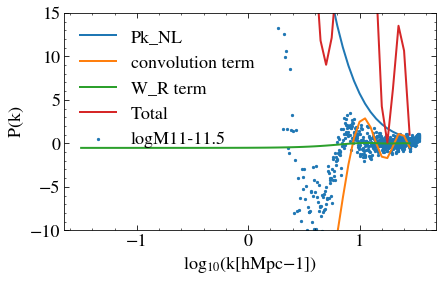

In [21]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
b_factor = b_const**2

plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Pnl(10**logks), label="Pk_NL")
plt.plot(logks, -b_factor*kernel_NL(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow(logks,R=R, kernel_type="nl"), label="Total")
#plt.ylim(-1,1)
plt.ylim(-10,15)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

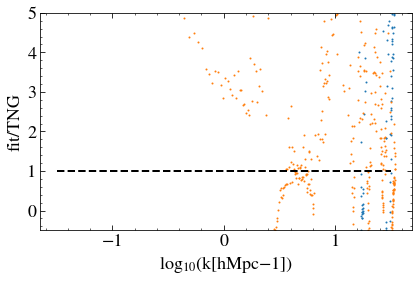

In [22]:
plt.scatter(np.log10(Pk110["k"]),fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="nl")/(Pk110["power"].real-Pk110.attrs["shotnoise"]),s=1)
plt.scatter(np.log10(Pk110["k"]),fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin")/(Pk110["power"].real-Pk110.attrs["shotnoise"]),s=1)

plt.ylim(-0.5,5)
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.ylabel("fit/TNG")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

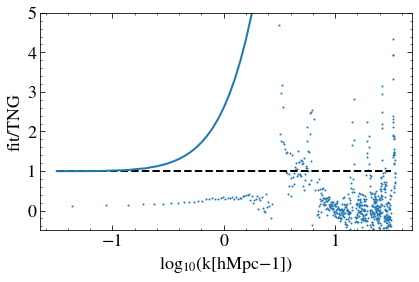

In [23]:
#plt.scatter(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"])/fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="nl"),s=1)
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="$Pk_{NL}/Pk_{lin}$")

plt.scatter(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"])/fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin"),s=1)

plt.ylim(-0.5,5)
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.ylabel("fit/TNG")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

### Fit bias

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

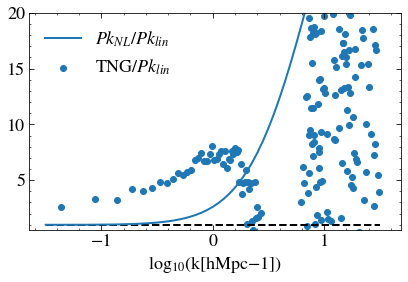

In [24]:
#ratio2[3] = Pnl(10**logk_tng[3])/Plin(10**logk_tng[3])
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="$Pk_{NL}/Pk_{lin}$")

#ratio2 = (Pk110["power"].real-Pk110.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_NL(Pk110["k"], R=R))/(fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin") + V_excl(R)*W_R(Pk110["k"], R)+ kernel_NL(Pk110["k"], R=R))
ratio2 = (Pk110["power"].real-Pk110.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_lin(Pk110["k"], R=R))/Plin(Pk110["k"])
#ratio2 = (Pk110["power"].real-Pk110.attrs["shotnoise"])/Plin(Pk110["k"])

#plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")
#ratio2 = (Pk110["power"].real-Pk110.attrs["shotnoise"])/(fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin"))

plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")
    
        
        
#plt.ylim(0.5,2)
plt.ylim(0.5,20)
plt.legend(loc="upper left")
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

In [25]:
def poly3(x, a, b, c, d, x0):
    return a + b*(x-x0) + c*(x-x0)**2 + d*(x-x0)**3

In [26]:
def new(k, k0, a):
    return k/k0 + a

In [27]:
def new_log(logk, logk0, a):
    
    return (10**logk/10**logk0) + a

In [28]:
mask = np.log10(Pk110["k"]) < 0
pop_fit1, pcov1 = curve_fit(new_log, np.log10(Pk110["k"][mask]),ratio2[mask],maxfev = 4000, sigma=None)


In [29]:
pop_fit1

array([-0.71314218,  2.81579608])

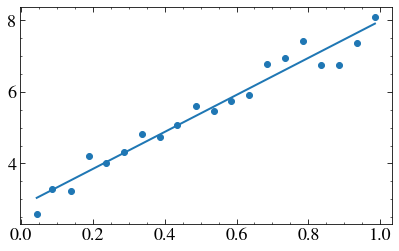

In [30]:
plt.scatter(Pk110["k"][mask],ratio2[mask], label="TNG/$Pk_{lin}$")
#plt.plot(Pk110["k"][:80], new(Pk110["k"][:80], *pop_fit2))
plt.plot(Pk110["k"][mask], new_log(np.log10(Pk110["k"][mask]), *pop_fit1))

(0.0, 10.0)

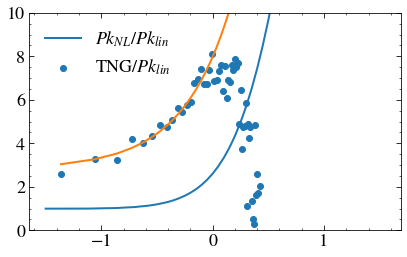

In [31]:
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="$Pk_{NL}/Pk_{lin}$")
plt.scatter(np.log10(Pk110["k"][:80]),ratio2[:80], label="TNG/$Pk_{lin}$")
#plt.plot(np.log10(Pk110["k"][:80]), new(Pk110["k"][:80], *pop_fit2), label="new")
#plt.plot(np.log10(Pk110["k"][:80]), poly3(np.log10(Pk110["k"][:80]), *pop_fit1), label="poly")
plt.plot(np.log10(Pk110["k"]), new_log(np.log10(Pk110["k"]), *pop_fit1))
plt.legend()
plt.ylim(0,10)

In [154]:
# def bias_fit(logks, pop_fit):
#     return poly3(logks, *pop_fit)

In [32]:
def bias_fit(logks, pop_fit):
    return new_log(logks, *pop_fit)

In [33]:
def Pnew(ks, pop_fit):
    logks = np.log10(ks)
    return bias_fit(logks,pop_fit)*Plin(ks)

In [34]:
# def bias_fit2(logks):
#     return new_test(logks)

# def Pnew(ks, pop_fit):
#     logks = np.log10(ks)
#     return bias_fit2(logks)*Plin(ks)

### Use new power spectrum for P term but still use linear power spectrum to compute kernel

In [35]:
def fit_pow_lin_kernel(logks, pop_fit, R=1, kernel_type="lin"):
  
    if kernel_type == "lin":
        Pk = Plin(10**logks)
        kernel = kernel_lin(10**logks, R=R)
    elif kernel_type == "new":
        kernel = kernel_new(10**logks, R=R)
    elif kernel_type == "nl":
        Pk = Pnl(10**logks)
        kernel = kernel_NL(10**logks, R=R)
    
    result1 = bias_fit(logks,pop_fit)*Pk - bias_fit(logks,pop_fit)*kernel - V_excl(R)*W_R(10**logks, R)
    
    return result1

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

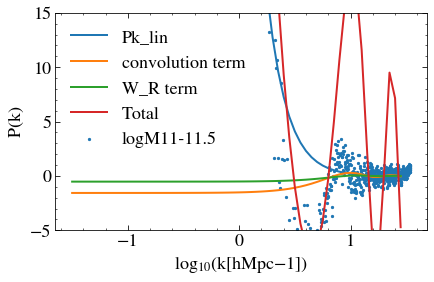

In [36]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks

b_factor = b_const**2
plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")


plt.plot(logks, b_factor*Plin(10**logks), label="Pk_lin")
plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow_lin_kernel(logks, pop_fit1, R=R), label="Total")
#plt.ylim(-1,500)
plt.ylim(-5,15)
#plt.ylim(-2,2)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

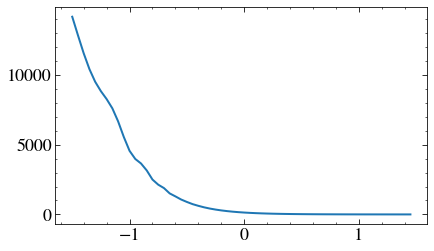

In [37]:
plt.plot(logks, bias_fit(logks, pop_fit1)*Plin(10**logks))

### Recompute power using new kernel

In [38]:
def kernel_new(ks_out, pop_fit, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(1e-4, dx, nbins)
    ks = np.linspace(10**-1.5, 10**1.5, 1000) # need many k bins in order to get good correlation function
    logks = np.log10(ks)
    xi = my_cf(ks, Pnew(ks, pop_fit),r)
    for k in ks_out:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [39]:
def kernel_new1(ks_out, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(1e-4, dx, nbins)
    ks = np.linspace(10**-1.5, 10**1.5, 1000) # need many k bins in order to get good correlation function
    logks = np.log10(ks)
    xi = my_cf(ks, Pnl(ks),r)
    for k in ks_out:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [40]:
kn = kernel_new1(10**logks, R=0.25)
knl = kernel_NL(10**logks, R=0.25)

(-1.0, 1.0)

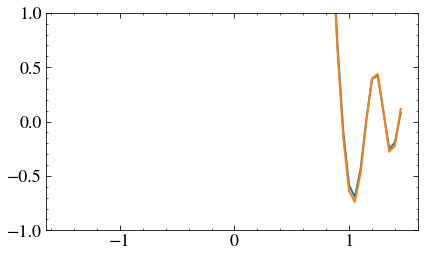

In [41]:
# Check that computation of kernel is okay
plt.plot(logks, kn)
plt.plot(logks, knl)
plt.ylim(-1,1)

Text(0, 0.5, '$- V_{excl}[W_R * P^{(c)}_{hh} ](k)$')

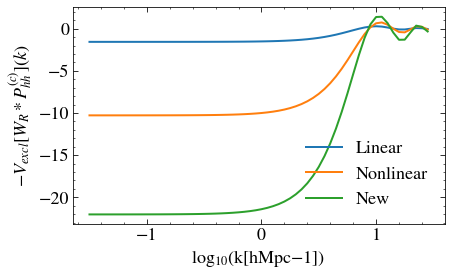

In [42]:
plt.plot(logks, -kernel_lin(10**logks, R=R), label="Linear")
plt.plot(logks, -kernel_NL(10**logks, R=R), label="Nonlinear")
plt.plot(logks, -kernel_new(10**logks, pop_fit1, R=R), label="New")
plt.legend()
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")
plt.ylabel("$- V_{excl}[W_R * P^{(c)}_{hh} ](k)$")

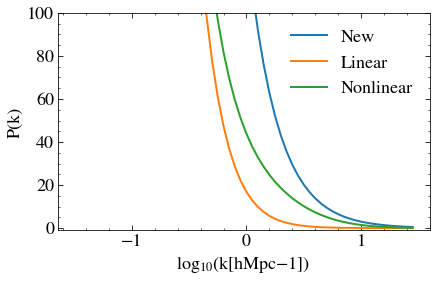

In [43]:
plt.plot(logks, Pnew(10**logks, pop_fit1), label="New")

plt.plot(logks, Plin(10**logks), label="Linear")
plt.plot(logks, Pnl(10**logks), label="Nonlinear")
plt.ylim(-1,100)
plt.ylabel("P(k)")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")
plt.legend()

In [44]:
def fit_pow_new(logk, pop_fit, R=1):
    Pk = Pnew(10**logk, pop_fit)
    kernel = kernel_new(10**logk, pop_fit, R=R)
    
    result1 = Pk - kernel - V_excl(R)*W_R(10**logk, R)
    
    return result1

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

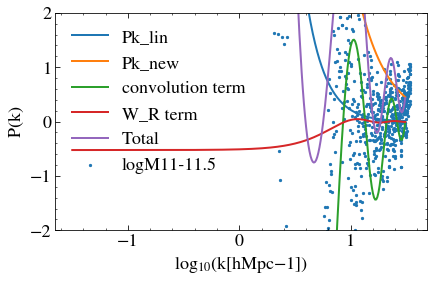

In [45]:
logks = np.arange(-1.5,1.5,0.01)
ks = 10**logks
b_factor = b_const**2
plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Plin(10**logks), label="Pk_lin")
plt.plot(logks, Pnew(10**logks, pop_fit1), label="Pk_new")
plt.plot(logks, -kernel_new(10**logks,pop_fit1, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow_new(logks,pop_fit1, R=R), label="Total")
plt.ylim(-1,500)
#plt.ylim(-5,15)
plt.ylim(-2,2)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

### Use new kernel and fit again

In [46]:
ratio3 = (Pk110["power"].real-Pk110.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_new(Pk110["k"], pop_fit1, R=R))/Plin(Pk110["k"])


In [47]:
ratio0 = (Pk110["power"].real-Pk110.attrs["shotnoise"])/Plin(Pk110["k"])


In [48]:

pop_fit3, pcov3 = curve_fit(new_log, np.log10(Pk110["k"][mask]),ratio3[mask],maxfev = 4000,p0=pop_fit1, sigma=None)


Text(0, 0.5, 'Relative to linear')

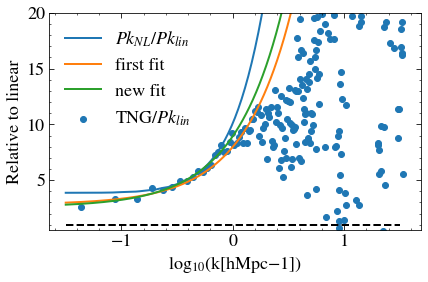

In [49]:
plt.plot(logks, Pnl(10**logks)/Plin(10**logks)*(b_const**2), label="$Pk_{NL}/Pk_{lin}$")

plt.scatter(np.log10(Pk110["k"]),ratio3, label="TNG/$Pk_{lin}$")
#plt.scatter(np.log10(Pk110["k"]),ratio0, label="TNG/$Pk_{lin} w/o exclusion$",s=1)

plt.plot(logks, bias_fit(logks, pop_fit1), label="first fit")
plt.plot(logks, bias_fit(logks, pop_fit3), label="new fit")

        
        
#plt.ylim(0.5,2)
plt.ylim(0.5,20)
plt.legend(loc="upper left")
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")
plt.ylabel("Relative to linear")


### Use new fit and kernel

Text(0, 0.5, '$- V_{excl}[W_R * P^{(c)}_{hh} ](k)$')

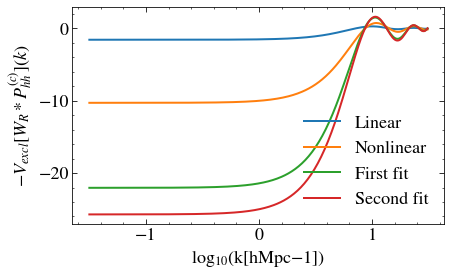

In [50]:
plt.plot(logks, -kernel_lin(10**logks, R=R), label="Linear")
plt.plot(logks, -kernel_NL(10**logks, R=R), label="Nonlinear")
plt.plot(logks, -kernel_new(10**logks, pop_fit1, R=R), label="First fit")

plt.plot(logks, -kernel_new(10**logks, pop_fit3, R=R), label="Second fit")
plt.legend()
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")
plt.ylabel("$- V_{excl}[W_R * P^{(c)}_{hh} ](k)$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

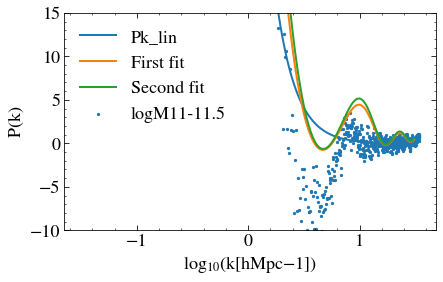

In [51]:
logks = np.arange(-1.5,1.5,0.01)
ks = 10**logks
b_factor = b_const**2
plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Plin(10**logks), label="Pk_lin")
#plt.plot(logks, Pnew(10**logks, pop_fit1), label="Pk_new")
#plt.plot(logks, -kernel_new(10**logks,pop_fit1, R=R), label="convolution term")
#plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow_new(logks,pop_fit1, R=R), label="First fit")

plt.plot(logks, fit_pow_new(logks,pop_fit3, R=R), label="Second fit")
#plt.ylim(-1,500)
plt.ylim(-10,15)
#plt.ylim(-2,2)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

(0.5, 1.5)

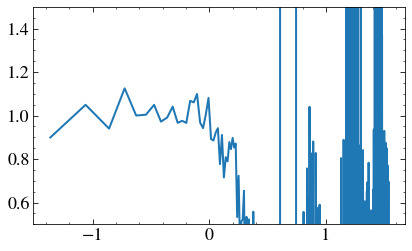

In [52]:


plt.plot(np.log10(Pk110["k"]), (Pk110["power"].real-Pk110.attrs["shotnoise"])/fit_pow_new(np.log10(Pk110["k"]),pop_fit3, R=R), label="Second fit")
plt.ylim(0.5,1.5)

### Check correlation function

In [77]:
def lognormal_cf(xi_c, sigma, R, r_list, bias=1):
    #dr = 0.00003
    #Nr = int( rmax / dr )
  
    #r_list = np.array([ dr * (i+1) for i in range(Nr) ])

    
    d = 2*R
    x = np.log10(r_list / d) / (np.sqrt(2) * sigma)
    fr = 1 - 0.5 * (1.0 + scipy.special.erf(x))
    if sigma == 0:
        xi_d = xi_c(r_list,bias=bias)
    else:
        xi_d = (1 - fr) * (xi_c(r_list, bias=bias) + 1) - 1

    return xi_d

In [70]:
def cf_nl_w_bias(r, bias=1, R=None):
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    return cf

In [71]:
tng_dir = "/cosma7/data/dp004/dc-zhan5/TNG/snap40/SubhaloFlag_all/mvir/ihalo"
tng_data = np.loadtxt(f"{tng_dir}/sfr-halomass_sum.txt")
mhalo_tng = tng_data[:,1]
pos_tng = tng_data[:,2:5]
sfr_tng = tng_data[:,5]


In [58]:
mask = mhalo_tng > 10
mhalo_tng = mhalo_tng[mask]
pos_tng = pos_tng[mask]
sfr_tng = sfr_tng[mask]

In [65]:
from Corrfunc.theory import xi as corrfunc_xi
boxsize=205
rmin = 0.01
rmax = 3.0
nbins = 100
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)

mask12 = (mhalo_tng > 12) & (mhalo_tng < 12.5)
pos_tng12 = pos_tng[mask12]

results12 = corrfunc_xi(boxsize, 2, rbins , pos_tng12[:,0],pos_tng12[:,1],pos_tng12[:,2], 
             weights=None,output_ravg=True)

(-2.0, 20.0)

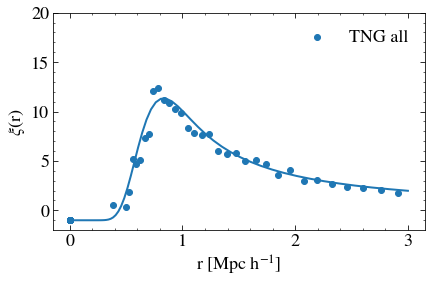

In [79]:
plt.scatter(results12["ravg"], results12["xi"], label="TNG all")
# plt.plot(rbins, cf_lin_excl(rbins, R=0.3), label="linear w exclusion")
#plt.plot(rbins, cf_nl_excl(rbins, bias=2, R=0.3), label="Halofit w exclusion")
cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.1, R=0.35, r_list=rbins)
plt.plot(rbins, cf_nl01)

#plt.scatter(np.log10(results["ravg"]), np.log10(results["xi"]))
plt.xlabel("r [Mpc h$^{-1}$]")
plt.ylabel(r"$\xi$(r)")
plt.legend()
#plt.xscale("log")
plt.ylim(-2,20)

In [80]:

cf1 = my_cf(10**logks, fit_pow_new(logks,pop_fit1, R=R), rbins)

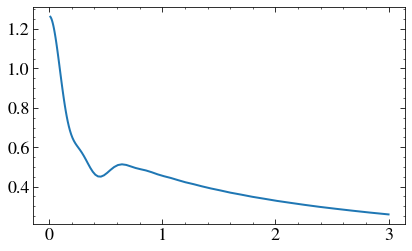

In [82]:
plt.plot(rbins, cf1)


### Fit using bias_fit and bias_corrected

In [352]:
bias_original = (Pk110["power"].real-Pk110.attrs["shotnoise"])/Plin(Pk110["k"])


(-20.0, 60.0)

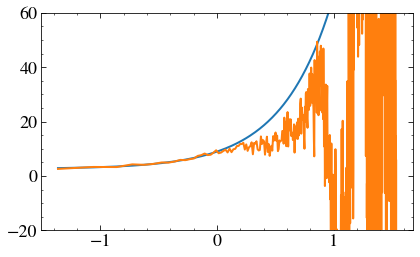

In [353]:
bias_corrected = (Pk110["power"].real-Pk110.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_new(Pk110["k"], pop_fit3, R=R))/Plin(Pk110["k"])

plt.plot(np.log10(Pk110["k"]),  bias_fit(np.log10(Pk110["k"]), pop_fit3))
plt.plot(np.log10(Pk110["k"]), bias_corrected)
plt.ylim(-20,60)

(-20.0, 60.0)

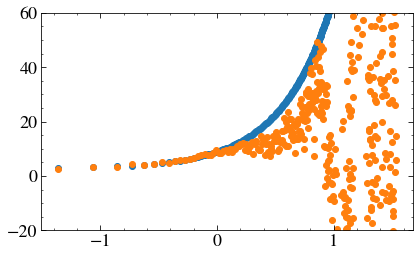

In [354]:
plt.scatter(np.log10(Pk110["k"]),  bias_fit(np.log10(Pk110["k"]), pop_fit3))
plt.scatter(np.log10(Pk110["k"]), bias_corrected)
plt.ylim(-20,60)

(-20.0, 50.0)

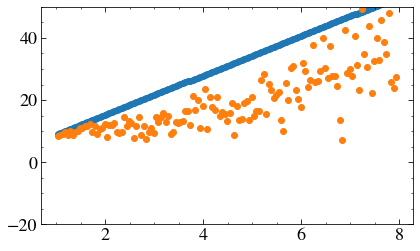

In [424]:
logk_tng = np.log10(Pk110["k"])
mask4 = (logk_tng < 0.9)&(logk_tng > 0)
plt.scatter(Pk110["k"][mask4],  bias_fit(np.log10(Pk110["k"][mask4]), pop_fit3))
plt.scatter(Pk110["k"][mask4], bias_corrected[mask4])

plt.ylim(-20,50)

In [356]:
combined_y = np.concatenate((bias_fit(np.log10(Pk110["k"][mask]), pop_fit3),bias_corrected[mask]))
combined_x = np.concatenate((np.log10(Pk110["k"][mask]),np.log10(Pk110["k"][mask])))


In [357]:
#mask = np.log10(Pk110["k"]) < 0
#pop_fit4, pcov1 = curve_fit(new_log, combined_x,combined_y,maxfev = 4000, sigma=None)


In [452]:
def new_log2(logk, m):
    
    # result = (10**logk/10**logk0) + a
    # mask = 10**logk > 1.6
    # result[mask] = -1*10**logk[mask] + 5
    # result = np.full(len(logk), 1)
    # mask = 10**logk < 1.6
    # result[mask] = Pnl(10**logk)/Plin(10**logk)
    logx0 = 0
    y0 = new_log(logx0, *pop_fit3)
    x0 = 10**logx0
    result =  m*((10**logk)-x0)**2 + y0
    
    return result

In [359]:
# #mask = np.log10(Pk110["k"]) < 0
pop_fit4, pcov1 = curve_fit(new_log2, np.log10(Pk110["k"][mask3]),bias_corrected[mask3],maxfev = 4000, sigma=None)


In [385]:
def bias_fit_tot(logks, pop_fit_low, pop_fit_high):
    bias_k = np.ones(len(logks))
    mask_low = logks < 0
    bias_k[mask_low] = new_log(logks[mask_low], *pop_fit_low)
    mask_high = logks > 0
    bias_k[mask_high] = new_log2(logks[mask_high], *pop_fit_high)
    #print(bias_k)
    return bias_k

In [386]:
def Pnew_tot(ks, pop_fit_low, pop_fit_high):
    logks = np.log10(ks)
    return bias_fit_tot(logks,pop_fit_low, pop_fit_high)*Plin(ks)

In [362]:
def new_test(logk):
    
    # result = (10**logk/10**logk0) + a
    # mask = 10**logk > 1.6
    # result[mask] = -1*10**logk[mask] + 5
    result = np.full(len(logk), b_factor)
    mask = logk < 0
    result[mask] = b_factor*Pnl(10**logk[mask])/Plin(10**logk[mask])
    
    return result

(0.0, 30.0)

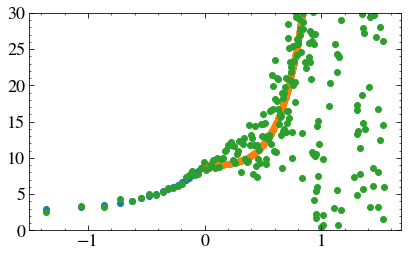

In [363]:
plt.scatter(np.log10(Pk110["k"][mask]),  new_log(np.log10(Pk110["k"][mask]), *pop_fit3))
plt.scatter(np.log10(Pk110["k"][mask4]),  new_log2(np.log10(Pk110["k"][mask4]), *pop_fit4))
plt.scatter(np.log10(Pk110["k"]),  bias_corrected)
#plt.scatter(np.log10(Pk110["k"]),  bias_original)
plt.ylim(0,30)

(0.0, 10.0)

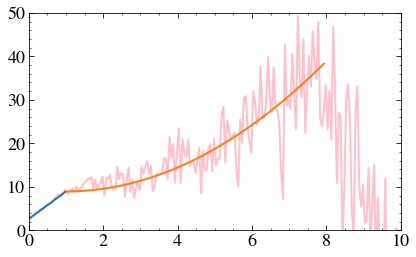

In [431]:
plt.plot(Pk110["k"],  bias_corrected, c="pink")
plt.plot(Pk110["k"][mask],  new_log(np.log10(Pk110["k"][mask]), *pop_fit3))
plt.plot(Pk110["k"][mask4],  new_log2(np.log10(Pk110["k"][mask4]), *pop_fit4))

#plt.scatter(np.log10(Pk110["k"]),  bias_original)
plt.ylim(0,50)
plt.xlim(0,10)

In [432]:
def kernel_new2(ks_out, Pnew, pop_fit1, pop_fit2, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(1e-4, dx, nbins)
    ks = np.linspace(10**-1.5, 10**1.5, 1000) # need many k bins in order to get good correlation function
    logks = np.log10(ks)
    xi = my_cf(ks, Pnew(ks, pop_fit1, pop_fit2),r)
    for k in ks_out:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

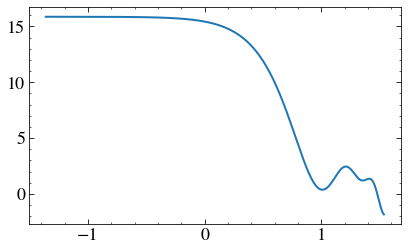

In [433]:
plt.plot(np.log10(Pk110["k"]), kernel_new2(Pk110["k"], Pnew_tot, pop_fit3, pop_fit4, R=R))

(-20.0, 60.0)

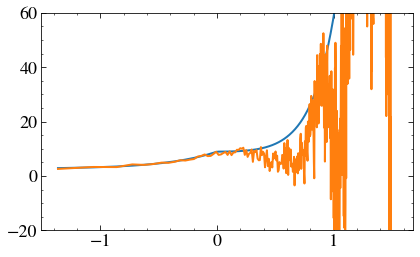

In [434]:
bias_corrected4 = (Pk110["power"].real-Pk110.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_new2(Pk110["k"], Pnew_tot, pop_fit3, pop_fit4, R=R))/Plin(Pk110["k"])

plt.plot(np.log10(Pk110["k"]),  bias_fit_tot(np.log10(Pk110["k"]), pop_fit3, pop_fit4))
plt.plot(np.log10(Pk110["k"]), bias_corrected4)
plt.ylim(-20,60)

(0.0, 10.0)

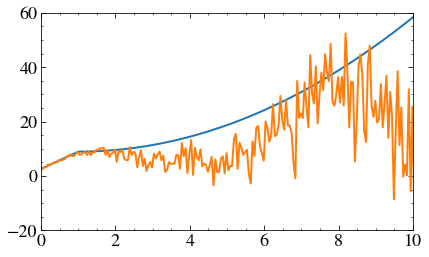

In [436]:
plt.plot(Pk110["k"],  bias_fit_tot(np.log10(Pk110["k"]), pop_fit3, pop_fit4))
plt.plot(Pk110["k"], bias_corrected4)
plt.ylim(-20,60)
plt.xlim(0,10)

In [437]:
def fit_pow_new2(logk, Pnew_tot, pop_fit1, pop_fit2, R=1):
    Pk = Pnew_tot(10**logk, pop_fit1, pop_fit2)
    #kernel = kernel_new(10**logk, pop_fit, R=R)
    kernel = kernel_new2(10**logk, Pnew_tot, pop_fit1, pop_fit2, R=R)
    print(len(Pk))
    print(len(kernel))
    result1 = Pk - kernel - V_excl(R)*W_R(10**logk, R)
    
    return result1

300
300


(-10.0, 10.0)

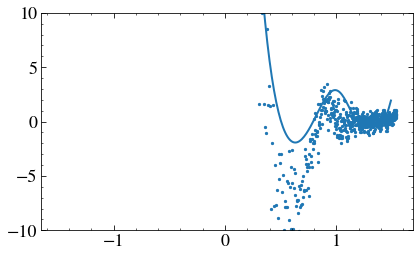

In [438]:
logks = np.arange(-1.5,1.5,0.01)
plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, fit_pow_new2(logks, Pnew_tot, pop_fit3, pop_fit4, R=R), label="Total")
plt.ylim(-10,10)

### Do again

In [439]:
# #mask = np.log10(Pk110["k"]) < 0
pop_fit5, pcov1 = curve_fit(new_log2, np.log10(Pk110["k"][mask4]),bias_corrected4[mask4],maxfev = 4000, sigma=None)


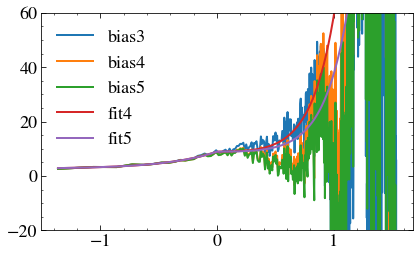

In [440]:
bias_corrected5 = (Pk110["power"].real-Pk110.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_new2(Pk110["k"], Pnew_tot, pop_fit3, pop_fit5, R=R))/Plin(Pk110["k"])

plt.plot(np.log10(Pk110["k"]), bias_corrected, label="bias3")
plt.plot(np.log10(Pk110["k"]), bias_corrected4, label="bias4")
plt.plot(np.log10(Pk110["k"]), bias_corrected5, label="bias5")
plt.plot(np.log10(Pk110["k"]),  bias_fit_tot(np.log10(Pk110["k"]), pop_fit3, pop_fit4), label="fit4")
plt.plot(np.log10(Pk110["k"]),  bias_fit_tot(np.log10(Pk110["k"]), pop_fit3, pop_fit5), label="fit5")

plt.ylim(-20,60)
plt.legend()

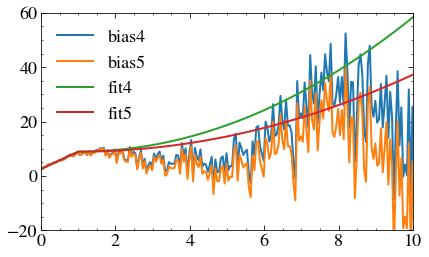

In [441]:
bias_corrected5 = (Pk110["power"].real-Pk110.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_new2(Pk110["k"], Pnew_tot, pop_fit3, pop_fit5, R=R))/Plin(Pk110["k"])

plt.plot(Pk110["k"], bias_corrected4, label="bias4")
plt.plot(Pk110["k"], bias_corrected5, label="bias5")
plt.plot(Pk110["k"],  bias_fit_tot(np.log10(Pk110["k"]), pop_fit3, pop_fit4), label="fit4")
plt.plot(Pk110["k"],  bias_fit_tot(np.log10(Pk110["k"]), pop_fit3, pop_fit5), label="fit5")

plt.ylim(-20,60)
plt.xlim(0,10)
plt.legend()

### Do again 2nd time

In [442]:
# #mask = np.log10(Pk110["k"]) < 0
pop_fit6, pcov1 = curve_fit(new_log2, np.log10(Pk110["k"][mask4]),bias_corrected5[mask4],maxfev = 4000, sigma=None)


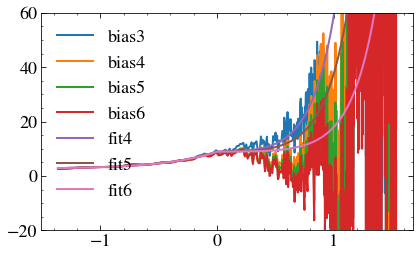

In [443]:
bias_corrected6 = (Pk110["power"].real-Pk110.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_new2(Pk110["k"], Pnew_tot, pop_fit3, pop_fit6, R=R))/Plin(Pk110["k"])

plt.plot(np.log10(Pk110["k"]), bias_corrected, label="bias3")
plt.plot(np.log10(Pk110["k"]), bias_corrected4, label="bias4")
plt.plot(np.log10(Pk110["k"]), bias_corrected5, label="bias5")
plt.plot(np.log10(Pk110["k"]), bias_corrected6, label="bias6")
plt.plot(np.log10(Pk110["k"]),  bias_fit_tot(np.log10(Pk110["k"]), pop_fit3, pop_fit4), label="fit4")
plt.plot(np.log10(Pk110["k"]),  bias_fit_tot(np.log10(Pk110["k"]), pop_fit3, pop_fit5), label="fit5")
plt.plot(np.log10(Pk110["k"]),  bias_fit_tot(np.log10(Pk110["k"]), pop_fit3, pop_fit6), label="fit6")

plt.ylim(-20,60)
plt.legend()

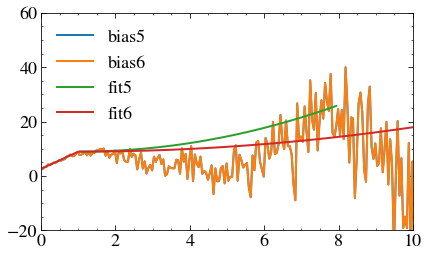

In [444]:
bias_corrected6 = (Pk110["power"].real-Pk110.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_new2(Pk110["k"], Pnew_tot, pop_fit3, pop_fit5, R=R))/Plin(Pk110["k"])
mask4 = (logk_tng < 0.9)&(logk_tng > 0)
plt.plot(Pk110["k"], bias_corrected5, label="bias5")
plt.plot(Pk110["k"], bias_corrected6, label="bias6")
plt.plot(Pk110["k"][mask4],  bias_fit_tot(np.log10(Pk110["k"][mask4]), pop_fit3, pop_fit5), label="fit5")
plt.plot(Pk110["k"],  bias_fit_tot(np.log10(Pk110["k"]), pop_fit3, pop_fit6), label="fit6")

plt.ylim(-20,60)
plt.xlim(0,10)
plt.legend()

### Try fitting simulataneously

In [445]:
p_c_terms = (Pk110["power"].real-Pk110.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R))             

In [490]:
def p_c_fit(logks, a, b, logk0_low, kernel_type="lin"):
    R=0.35
    pop_fit_low = [logk0_low, a]
    pop_fit_high = [b]
    
    bias_factor_k = bias_fit_tot(logks, pop_fit_low, pop_fit_high)
    
  
    Pk = Plin(10**logks)
  
    
    kernel = kernel_new2(10**logks, Pnew_tot, pop_fit_low, pop_fit_high,R=R)
    result1 = bias_factor_k*Pk - kernel
    
    return result1

In [491]:

pc_fit1, pcov1 = curve_fit(p_c_fit, np.log10(Pk110["k"]),p_c_terms,maxfev = 4000, sigma=None)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/scipy/optimize/minpack.py:829: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


In [492]:
pc_fit1

array([ 2.25195933,  1.05200206, -0.95220446,  1.        ])

(-20.0, 20.0)

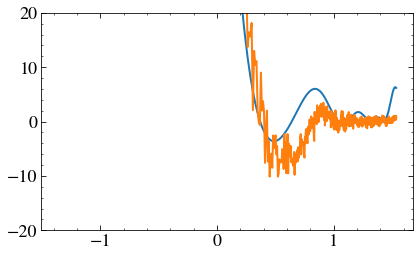

In [493]:
plt.plot(np.log10(Pk110["k"]),p_c_fit(np.log10(Pk110["k"]), *pc_fit1))
plt.plot(np.log10(Pk110["k"]),p_c_terms)
plt.ylim(-20,20)